# Six-hour PM2.5 forecasting

This report uses the production loader, feature builder and evaluation code. It shows aggregate results only; raw sensor records are not displayed.

Data contributed by The Demography Project; data provided by [AirGradient](https://www.airgradient.com) via [OpenAQ](https://openaq.org). Licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        project = candidate if candidate.name == 'air-quality-forecasting' else candidate / 'projects' / 'air-quality-forecasting'
        if (project / 'pyproject.toml').exists():
            return project
    raise RuntimeError('Run this notebook from the repository or project directory.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from air_quality_forecasting.data import load_hourly_measurements
from air_quality_forecasting.evaluate import MODEL_NAME, expanding_windows, run_experiment, split_final_holdout
from air_quality_forecasting.features import TARGET_TIME_COLUMN, make_supervised_dataset

data_files = sorted((PROJECT_ROOT / 'data').glob('openaq_location_*.csv'))
if not data_files:
    raise FileNotFoundError('Fetch the OpenAQ dataset before running this notebook.')
DATA_PATH = data_files[-1]
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Using data/{DATA_PATH.name}')

Using data/openaq_location_5199863_2025-07-25_2026-09-08.csv


## Coverage and missing data

The loader creates a regular hourly index without filling gaps. Every summary and plot in the exploratory sections uses only the first validation window's training partition; all validation windows and the final holdout remain unseen during EDA.

In [2]:
hourly, _ = load_hourly_measurements(DATA_PATH)
dataset, feature_columns = make_supervised_dataset(hourly)
development, _, holdout_start = split_final_holdout(dataset)
eda_training, first_validation = expanding_windows(development)[0]
eda_hourly = hourly.loc[:eda_training[TARGET_TIME_COLUMN].max()]
observed_pm25 = int(eda_hourly['pm25'].notna().sum())
largest_gap = eda_hourly['pm25'].dropna().index.to_series().diff().max()
eda_profile = {
    'partition': 'first validation window training only',
    'hourly_rows': len(eda_hourly),
    'start_utc': eda_hourly.index.min().isoformat(),
    'end_utc': eda_hourly.index.max().isoformat(),
    'pm25_missing_hours': int(eda_hourly['pm25'].isna().sum()),
    'pm25_coverage_percent': round(100 * observed_pm25 / len(eda_hourly), 2),
    'largest_observation_gap_hours': int(largest_gap / pd.Timedelta('1h')),
    'first_validation_start_utc': first_validation.index.min().isoformat(),
    'holdout_start_utc': holdout_start.isoformat(),
}
pd.Series(eda_profile, name='value').to_frame()

,value
partition,first validation window training only
hourly_rows,5474
start_utc,2025-07-25T10:00:00+00:00
end_utc,2026-03-10T11:00:00+00:00
pm25_missing_hours,539
pm25_coverage_percent,90.15
largest_observation_gap_hours,92
first_validation_start_utc,2026-03-10T12:00:00+00:00
holdout_start_utc,2026-08-07T04:00:00+00:00


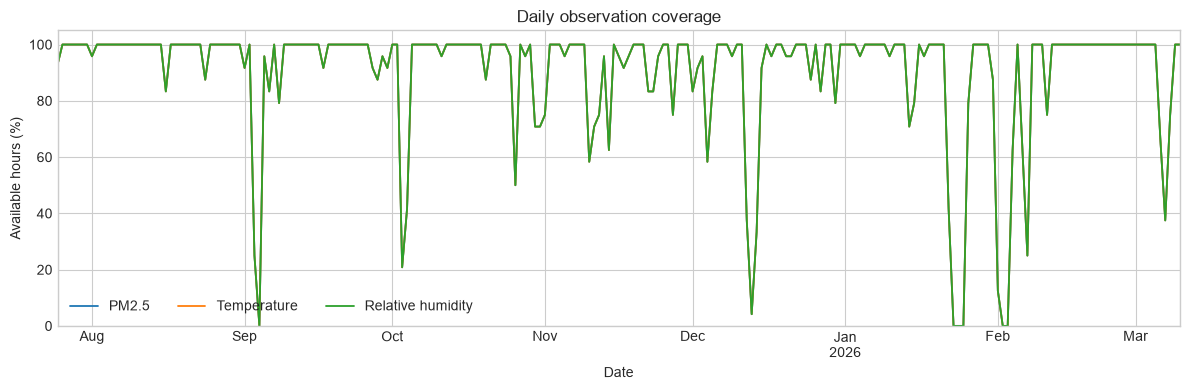

In [3]:
daily_coverage = eda_hourly.notna().resample('D').mean().mul(100)
ax = daily_coverage.plot(figsize=(12, 4), linewidth=1.3)
ax.set(title='Daily observation coverage', xlabel='Date', ylabel='Available hours (%)', ylim=(0, 105))
ax.legend(['PM2.5', 'Temperature', 'Relative humidity'], ncol=3)
plt.tight_layout()
plt.show()

Coverage is generally aligned across the three signals, but several gaps are long enough to affect lag and rolling features. The pipeline preserves these gaps and lets the tree model handle missing inputs.

## PM2.5 behavior

The distribution and hourly medians show a right-skewed target with a repeatable daily pattern. These patterns support nonlinear lag features and a strong 24-hour seasonal baseline.

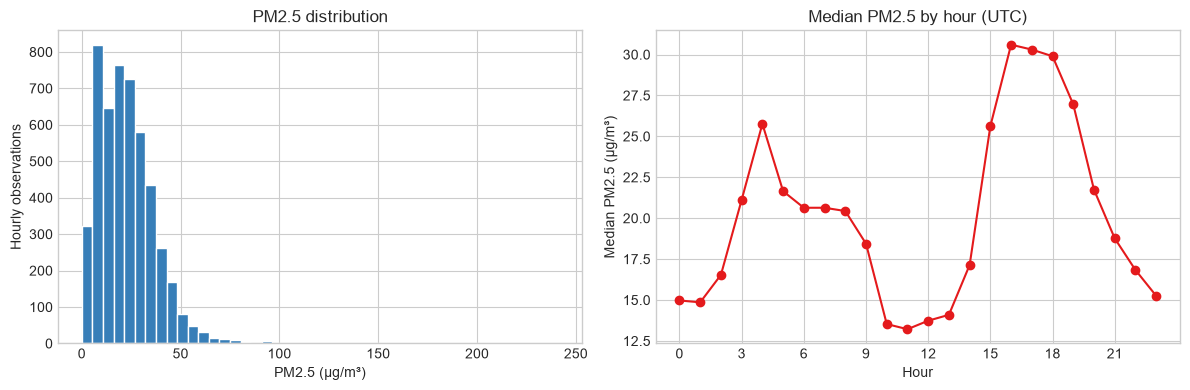

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eda_hourly['pm25'].plot.hist(bins=45, ax=axes[0], color='#377eb8', edgecolor='white')
axes[0].set(title='PM2.5 distribution', xlabel='PM2.5 (µg/m³)', ylabel='Hourly observations')
diurnal = eda_hourly['pm25'].groupby(eda_hourly.index.hour).median()
diurnal.plot(ax=axes[1], marker='o', color='#e41a1c')
axes[1].set(title='Median PM2.5 by hour (UTC)', xlabel='Hour', ylabel='Median PM2.5 (µg/m³)', xticks=range(0, 24, 3))
plt.tight_layout()
plt.show()

## Chronological model comparison

Four expanding windows compare the model with persistence and 24-hour seasonal-naive predictions. Training targets are embargoed from each later validation period. The latest 30 days remain untouched until final evaluation.

In [5]:
result = run_experiment(dataset, feature_columns)
result.validation_summary

,candidate,mean_mae,windows_won
0,hist_gradient_boosting,8.303960,3
1,seasonal_naive_24h,8.916876,1
2,persistence,11.473298,0


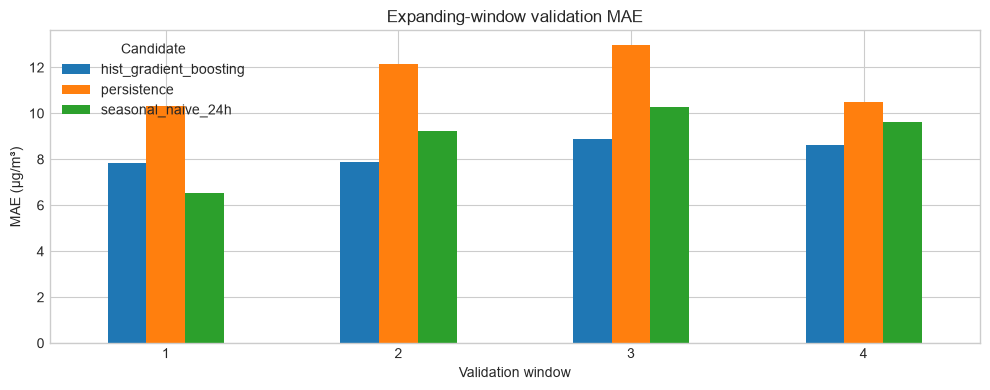

In [6]:
validation_plot = result.validation_metrics.pivot(index='window', columns='candidate', values='mae')
ax = validation_plot.plot(kind='bar', figsize=(10, 4), rot=0)
ax.set(title='Expanding-window validation MAE', xlabel='Validation window', ylabel='MAE (µg/m³)')
ax.legend(title='Candidate')
plt.tight_layout()
plt.show()

The boosted-tree model has the lowest mean validation MAE and wins three of four windows. The seasonal baseline remains competitive, so the final holdout comparison is important.

In [7]:
result.holdout_metrics

,candidate,mae
0,hist_gradient_boosting,9.774422
1,seasonal_naive_24h,10.028660
2,persistence,12.577113


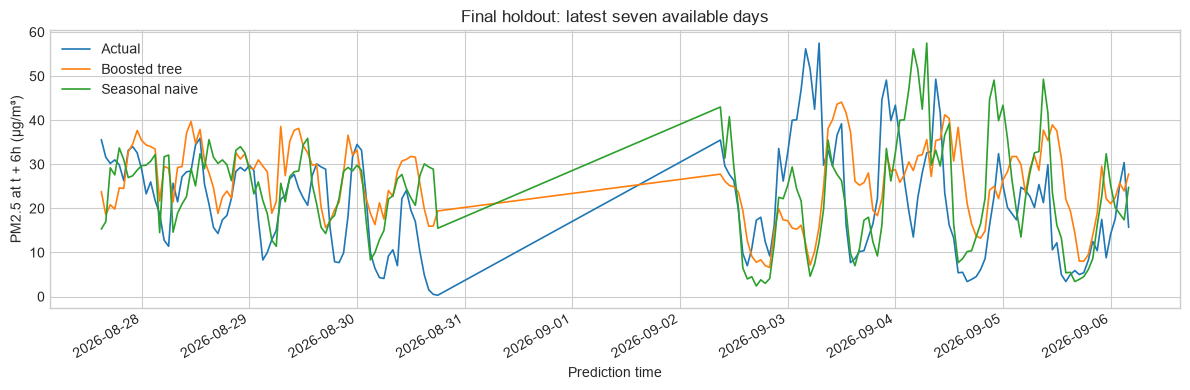

In [8]:
recent = result.holdout_predictions.tail(24 * 7)
ax = recent[['actual_pm25', MODEL_NAME, 'seasonal_naive_24h']].plot(figsize=(12, 4), linewidth=1.2)
ax.set(title='Final holdout: latest seven available days', xlabel='Prediction time', ylabel='PM2.5 at t + 6h (µg/m³)')
ax.legend(['Actual', 'Boosted tree', 'Seasonal naive'])
plt.tight_layout()
plt.show()

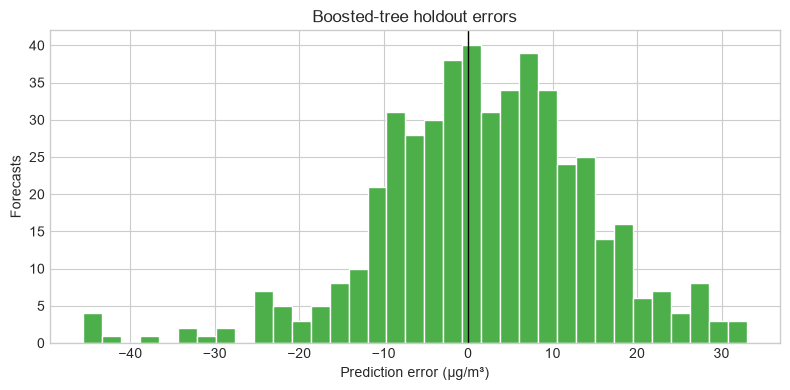

In [9]:
errors = result.holdout_predictions[MODEL_NAME] - result.holdout_predictions['actual_pm25']
ax = errors.plot.hist(bins=35, figsize=(8, 4), color='#4daf4a', edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set(title='Boosted-tree holdout errors', xlabel='Prediction error (µg/m³)', ylabel='Forecasts')
plt.tight_layout()
plt.show()

## Findings and implications

- The initial training partition is used for EDA; later validation windows and the final holdout remain untouched until evaluation.
- `HistGradientBoostingRegressor` achieved 8.304 mean validation MAE, ahead of seasonal naive at 8.917 and persistence at 11.473.
- Holdout MAE was 9.774 for the model, 10.029 for seasonal naive and 12.577 for persistence.
- The model passes the exercise criteria, but its small holdout advantage over seasonal naive needs confirmation.
- Results come from one station. Missing periods, unobserved weather drivers and location-specific behavior limit generalization. Additional locations and later temporal holdouts are the next useful tests.